# Machine Learning Capstone — Classification Track

**Review 1**
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine (SVC)

In [1]:
# 2. Import required libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    BaggingClassifier
)

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# 3. Load dataset

DATA_PATH = "LOS_CausalFeatures_LosAngeles.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (28092, 51)


,GEOID20,City,Congestion_Index,LOS_actual,Ave_Height,B08301_002E,B08301_003E,B08301_004E,B08301_005E,B08301_010E,...,PM25,Residential_Area,Residential_Pct,Total_Parcel_Count,Transportation_Pct,Vacant_Undeveloped_Pct,to_fire,to_hospital,to_police,LOS_actual_numeric
0,6.037103e+13,Los Angeles,4.0,Medium,3.3624,124.0,101.0,23.0,0.0,0.0,...,9.536130,55722.330024,100.0,90.0,0.0,0.0,0.933333,12.000000,12.000000,2.0
1,6.037134e+13,Los Angeles,0.0,Poor,2.7760,691.0,638.0,53.0,14.0,0.0,...,8.144902,13614.689279,100.0,19.0,0.0,0.0,2.000000,3.666667,3.666667,3.0
2,6.037132e+13,Los Angeles,1.0,Good,3.6105,397.0,298.0,99.0,99.0,16.0,...,8.798196,18838.810578,100.0,32.0,0.0,0.0,2.000000,8.000000,8.000000,1.0
3,6.037132e+13,Los Angeles,1.0,Good,3.7287,390.0,332.0,58.0,58.0,0.0,...,8.798894,17417.579813,100.0,30.0,0.0,0.0,2.000000,6.800000,6.800000,1.0
4,6.037132e+13,Los Angeles,2.0,Good,4.2516,384.0,373.0,11.0,11.0,0.0,...,8.800632,40631.880676,100.0,73.0,0.0,0.0,2.363636,6.000000,6.000000,1.0


#  1. Dataset Loading & Audit

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nBasic statistics:")
display(df.describe(include="all").T)

print("\nUnique values:")
for column in df.columns:
    print(f"{column}: {df[column].nunique(dropna=True)} unique values")

Number of rows: 28092
Number of columns: 51
Dataset shape: (28092, 51)

Data types:


,dtype
GEOID20,float64
City,str
Congestion_Index,float64
LOS_actual,str
Ave_Height,float64
B08301_002E,float64
B08301_003E,float64
B08301_004E,float64
B08301_005E,float64
B08301_010E,float64



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GEOID20,28092.0,NaN,NaN,NaN,60372090429745.554688,1237956284.952549,60371011101000.0,60371319002001.75,60372036012004.5,60372403012004.25,60379800391002.0
City,28092,1,Los Angeles,28092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Congestion_Index,28092.0,NaN,NaN,NaN,2.686032,1.326739,0.0,2.0,3.0,4.0,6.0
LOS_actual,28092,3,Medium,12962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ave_Height,28090.0,NaN,NaN,NaN,3.730212,2.304791,0.0,2.677025,3.4331,4.38275,44.2804
B08301_002E,28090.0,NaN,NaN,NaN,507.412424,281.39734,0.0,317.0,462.0,655.0,2705.0
B08301_003E,28090.0,NaN,NaN,NaN,445.939943,249.746579,0.0,275.0,405.0,579.0,2348.0
B08301_004E,28090.0,NaN,NaN,NaN,61.472481,62.10383,0.0,16.0,43.0,87.0,427.0
B08301_005E,28090.0,NaN,NaN,NaN,46.077038,49.497543,0.0,9.0,31.0,66.0,369.0
B08301_010E,28090.0,NaN,NaN,NaN,37.838875,56.313308,0.0,0.0,16.0,53.0,856.0



Unique values:
GEOID20: 28091 unique values
City: 1 unique values
Congestion_Index: 7 unique values
LOS_actual: 3 unique values
Ave_Height: 20619 unique values
B08301_002E: 895 unique values
B08301_003E: 816 unique values
B08301_004E: 267 unique values
B08301_005E: 224 unique values
B08301_010E: 266 unique values
B08301_018E: 82 unique values
B08301_019E: 174 unique values
B08301_021E: 430 unique values
B15003_001E: 1269 unique values
B19013_001E: 2337 unique values
B19301_001E: 2663 unique values
B23025_003E: 1124 unique values
B23025_005E: 250 unique values
BLOK_Compact: 28091 unique values
BLOK_Convex: 18775 unique values
BLOK_Elong: 28091 unique values
B_Compactness_Mean: 25601 unique values
B_Compactness_Median: 25522 unique values
B_Elongation_Mean: 25601 unique values
B_Elongation_Median: 25520 unique values
Block_Total_Area: 25519 unique values
Build_Cov_Ratio: 24808 unique values
Commercial_Area: 7612 unique values
Commercial_Pct: 3789 unique values
Crash_Inde: 28063 unique v

## Missing-value and duplicate audit

In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Total missing values:", missing_values.sum())
display(missing_values[missing_values > 0])

Total missing values: 54819


Build_Cov_Ratio           3283
B19013_001E               2722
Block_Total_Area          2572
Mixed_Use_Area            2572
Mixed_Use_Pct             2572
Residential_Area          2572
Open_Space_Pct            2572
Vacant_Undeveloped_Pct    2572
Transportation_Pct        2572
Total_Parcel_Count        2572
Residential_Pct           2572
Institutional_Pct         2572
Commercial_Area           2572
Industrial_Pct            2572
Industrial_Area           2572
Commercial_Pct            2572
B_Compactness_Median      2447
B_Elongation_Mean         2447
N_B_Vertx                 2447
B_Elongation_Median       2447
B_Compactness_Mean        2447
B19301_001E                262
Elementary_sch             138
High_school                133
Crash_Inde                   8
Ave_Height                   2
B23025_005E                  2
B08301_004E                  2
B08301_003E                  2
B08301_005E                  2
B08301_010E                  2
B08301_002E                  2
B08301_0

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


## Target audit

In [7]:
target = "LOS_actual"

print("Target variable:", target)
print("\nTarget distribution:")
display(df[target].value_counts())

print("\nTarget percentages:")
display((df[target].value_counts(normalize=True) * 100).round(2))

Target variable: LOS_actual

Target distribution:


LOS_actual
Medium    12962
Good      12012
Poor       3118
Name: count, dtype: int64


Target percentages:


LOS_actual
Medium    46.14
Good      42.76
Poor      11.10
Name: proportion, dtype: float64

# 2. Exploratory Data Analysis

In [8]:
# Identify columns

numeric_features_all = df.select_dtypes(include=np.number).columns.tolist()
categorical_features_all = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_features_all)

print("\nCategorical columns:")
print(categorical_features_all)

Numerical columns:
['GEOID20', 'Congestion_Index', 'Ave_Height', 'B08301_002E', 'B08301_003E', 'B08301_004E', 'B08301_005E', 'B08301_010E', 'B08301_018E', 'B08301_019E', 'B08301_021E', 'B15003_001E', 'B19013_001E', 'B19301_001E', 'B23025_003E', 'B23025_005E', 'BLOK_Compact', 'BLOK_Convex', 'BLOK_Elong', 'B_Compactness_Mean', 'B_Compactness_Median', 'B_Elongation_Mean', 'B_Elongation_Median', 'Block_Total_Area', 'Build_Cov_Ratio', 'Commercial_Area', 'Commercial_Pct', 'Crash_Inde', 'Elementary_sch', 'High_school', 'Industrial_Area', 'Industrial_Pct', 'Institutional_Pct', 'Length', 'Mixed_Use_Area', 'Mixed_Use_Pct', 'N_B_Vertx', 'Open_Space_Pct', 'P1_001N', 'PM25', 'Residential_Area', 'Residential_Pct', 'Total_Parcel_Count', 'Transportation_Pct', 'Vacant_Undeveloped_Pct', 'to_fire', 'to_hospital', 'to_police', 'LOS_actual_numeric']

Categorical columns:
['City', 'LOS_actual']


In [9]:
excluded_from_model = ["LOS_actual", "LOS_actual_numeric", "GEOID20", "City"]

eda_numeric_features = [
    c for c in numeric_features_all
    if c not in ["LOS_actual_numeric", "GEOID20"]
]

eda_categorical_features = [
    c for c in categorical_features_all
    if c != "LOS_actual"
]

print("EDA numerical features:", len(eda_numeric_features))
print("EDA categorical features:", eda_categorical_features)

EDA numerical features: 47
EDA categorical features: ['City']


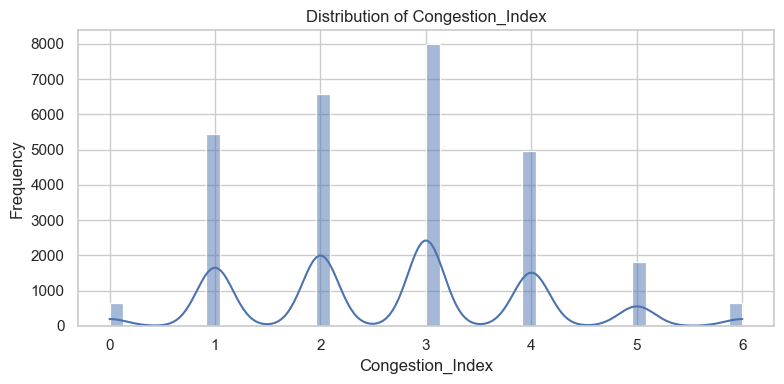

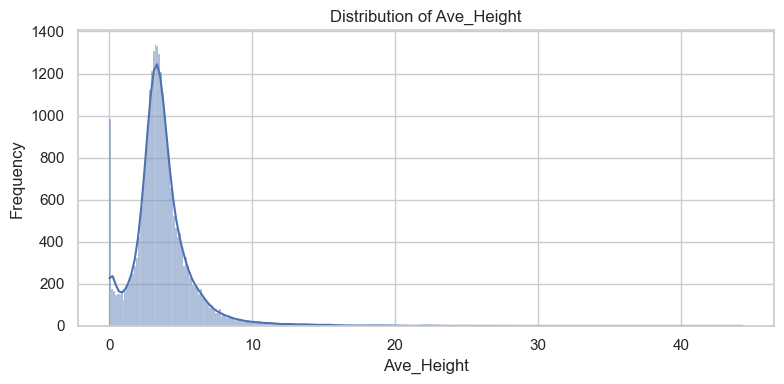

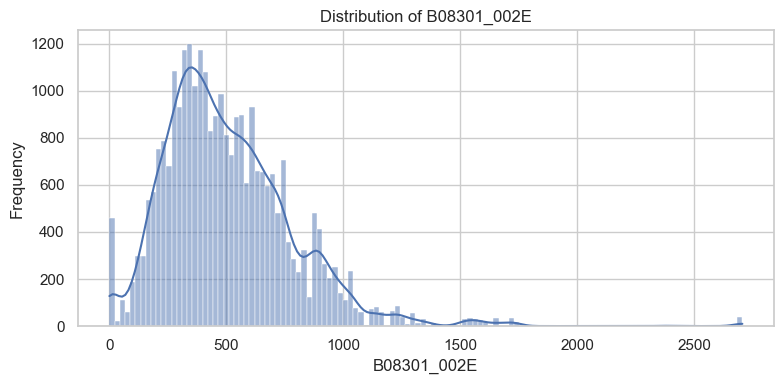

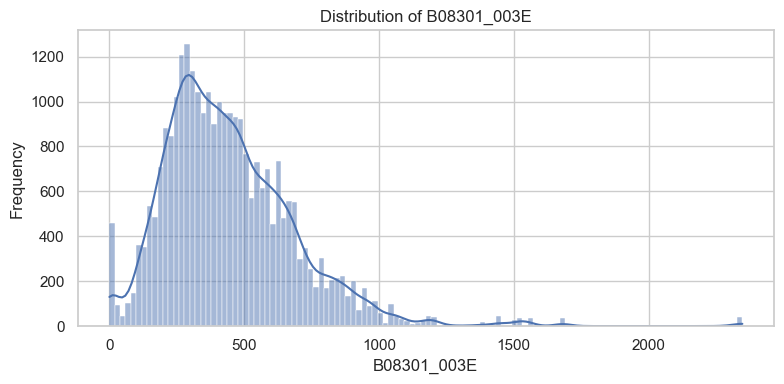

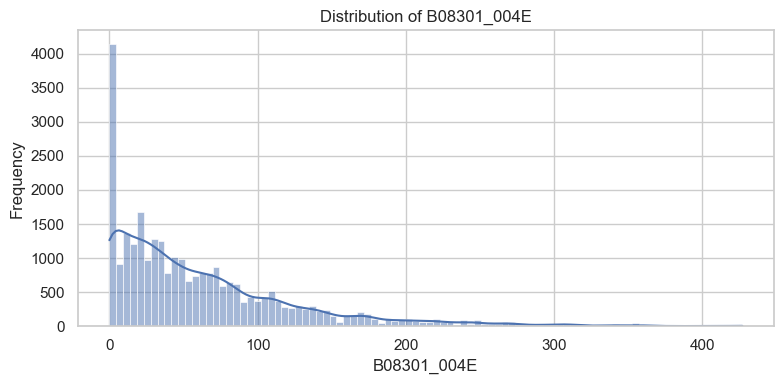

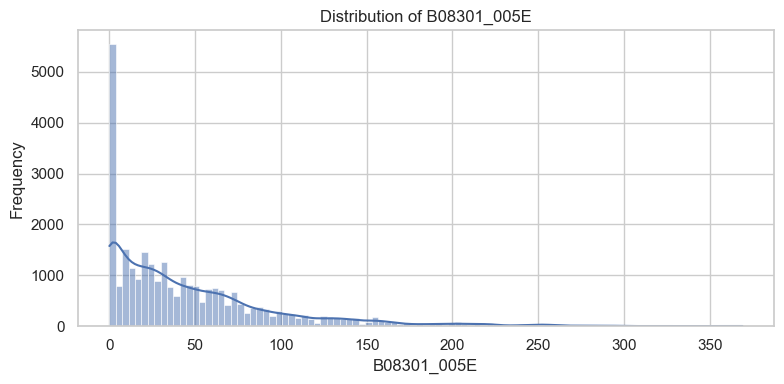

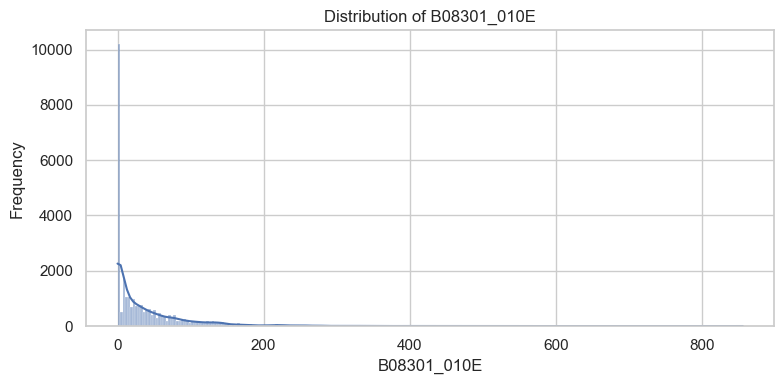

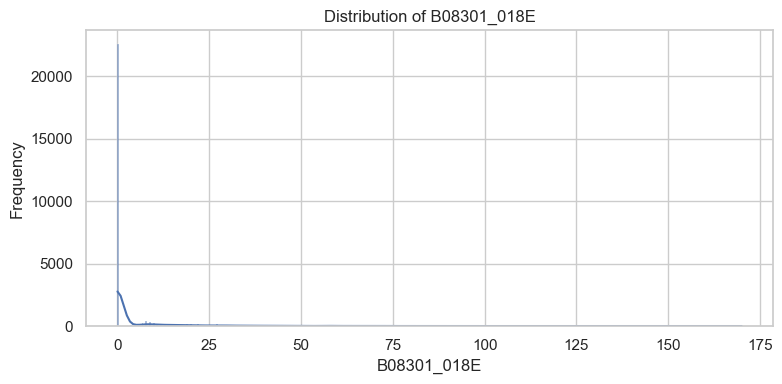

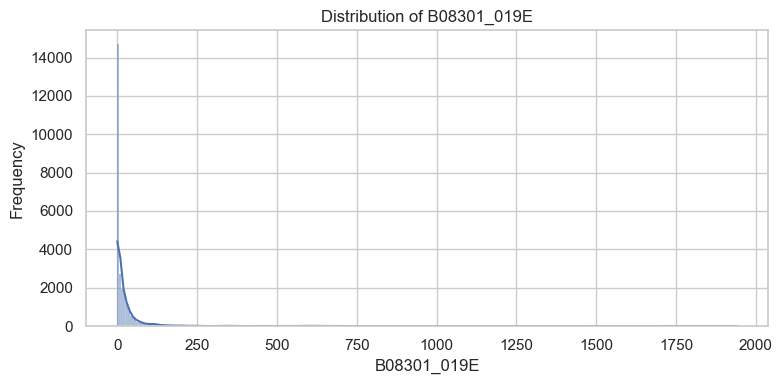

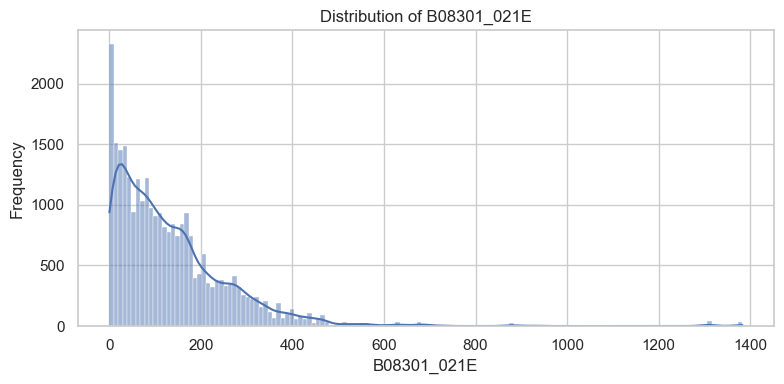

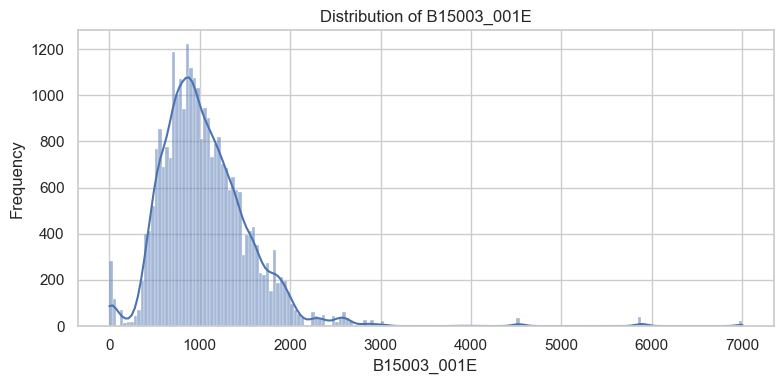

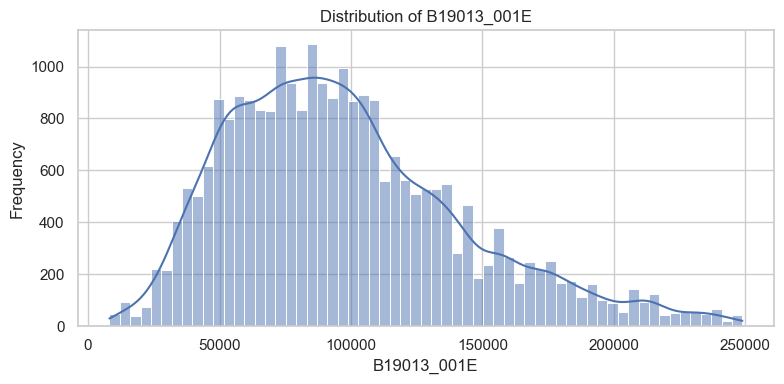

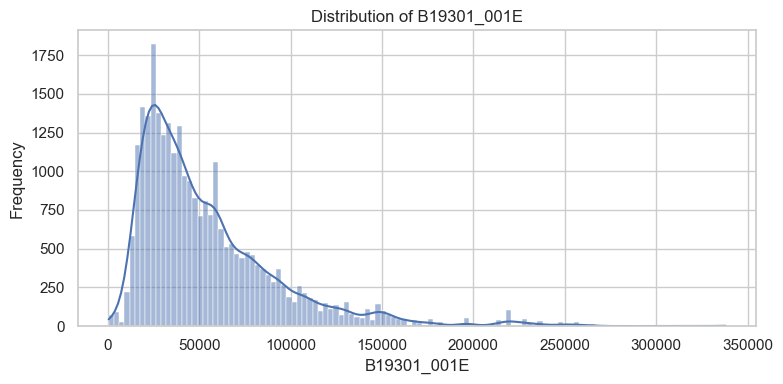

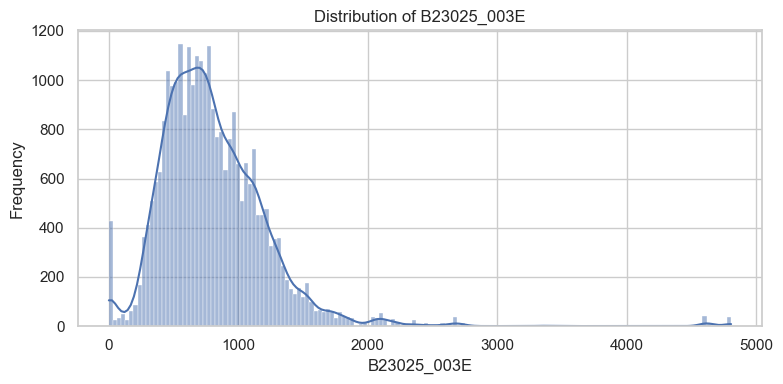

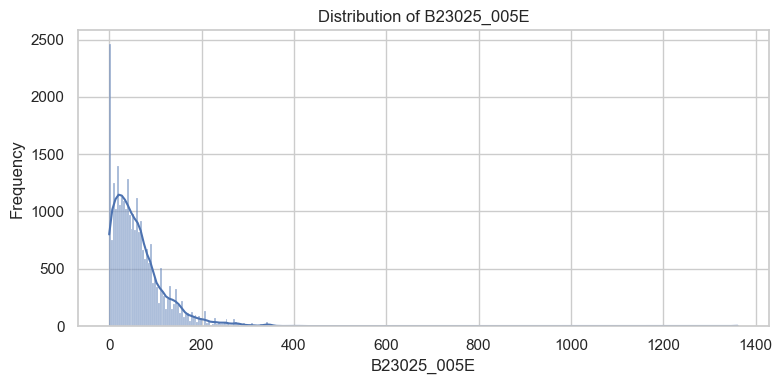

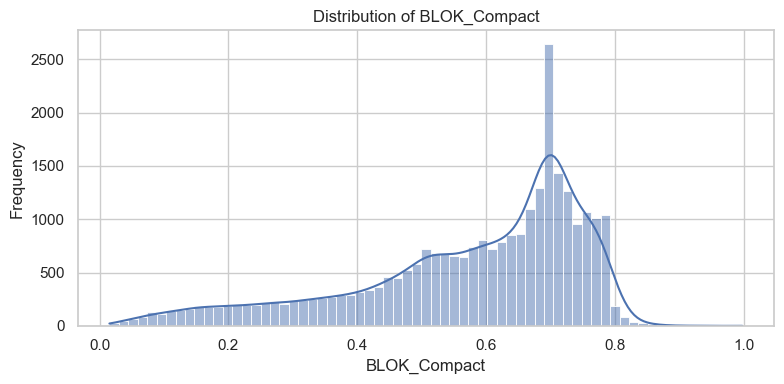

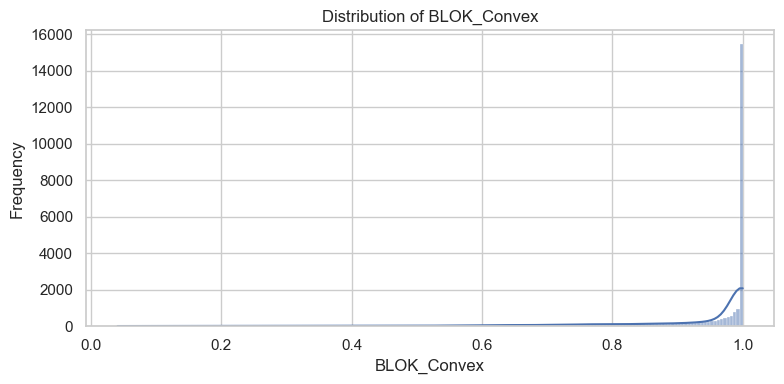

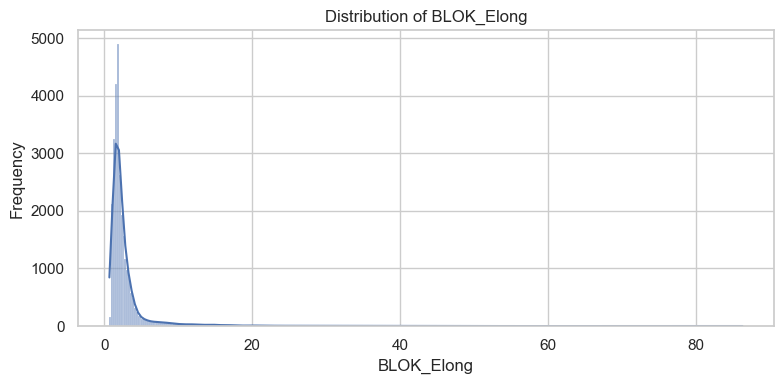

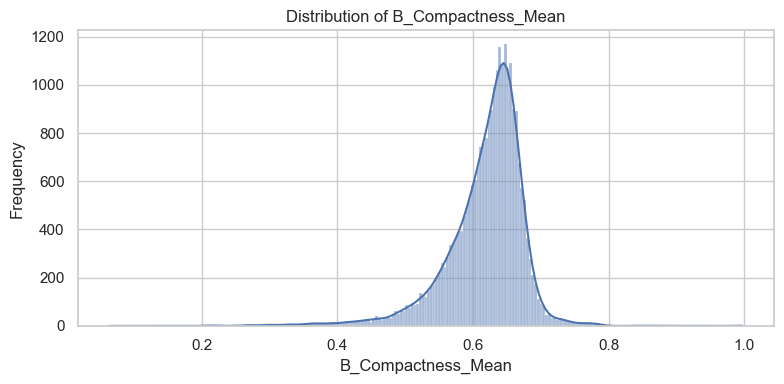

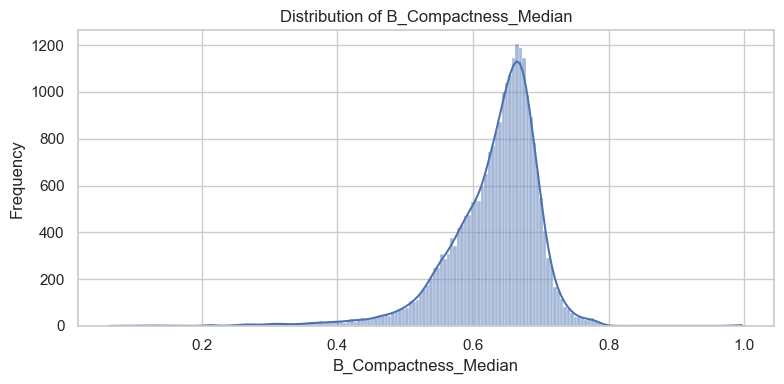

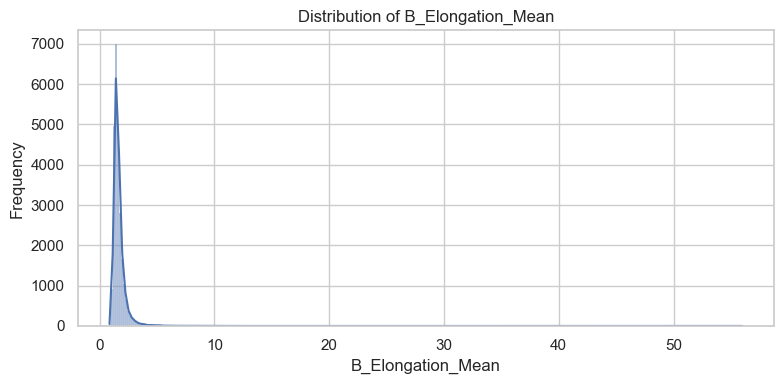

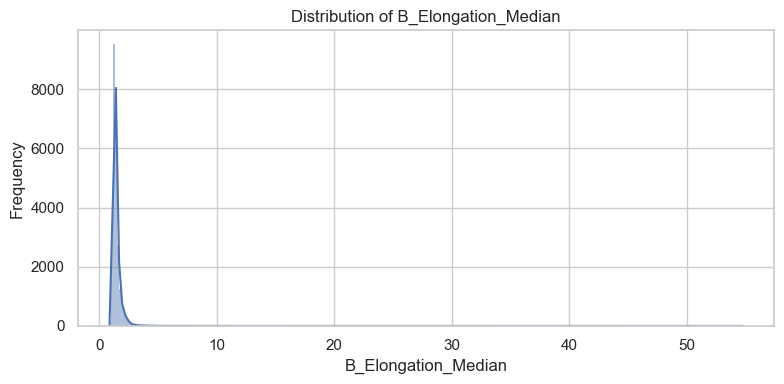

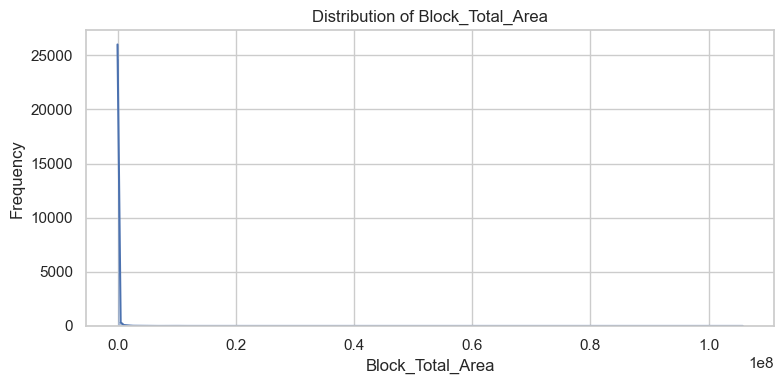

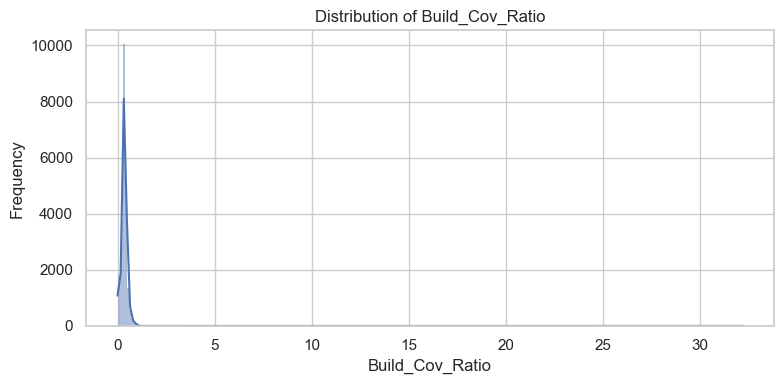

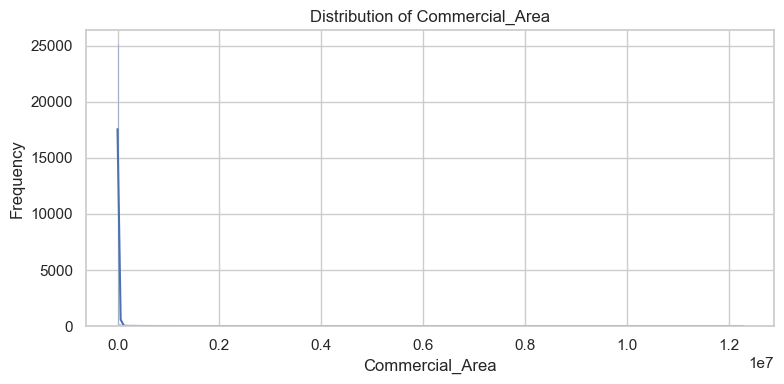

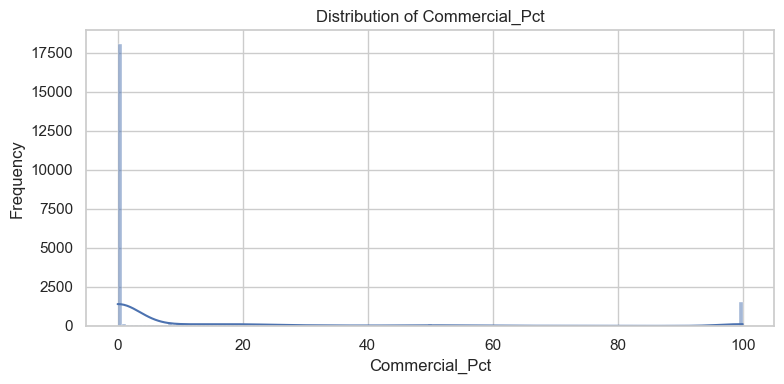

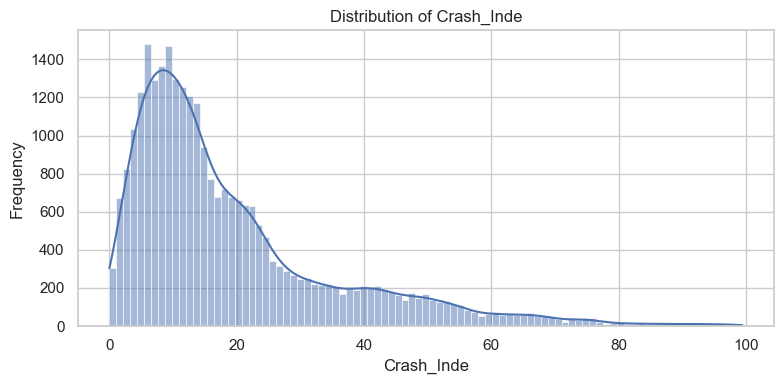

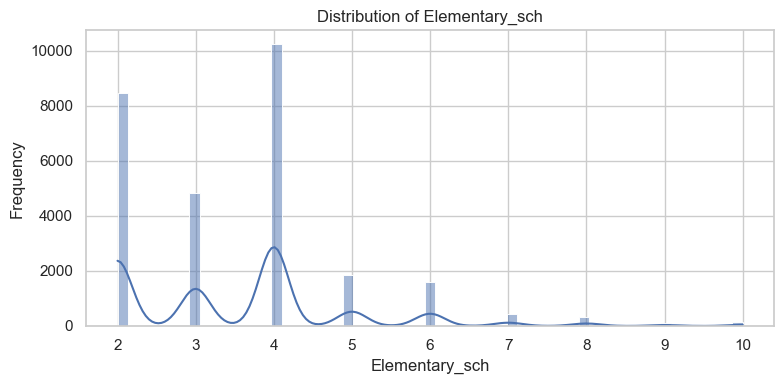

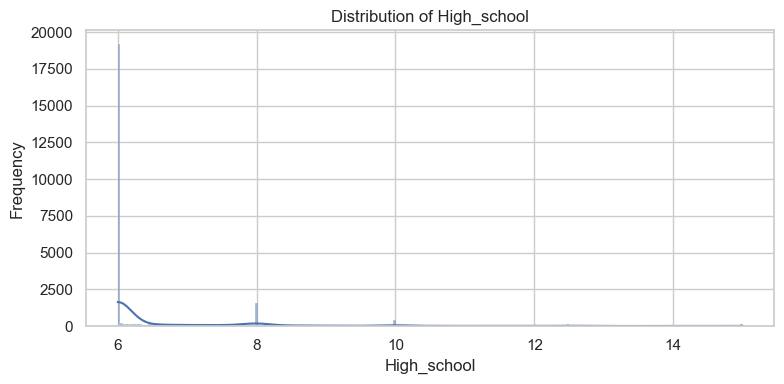

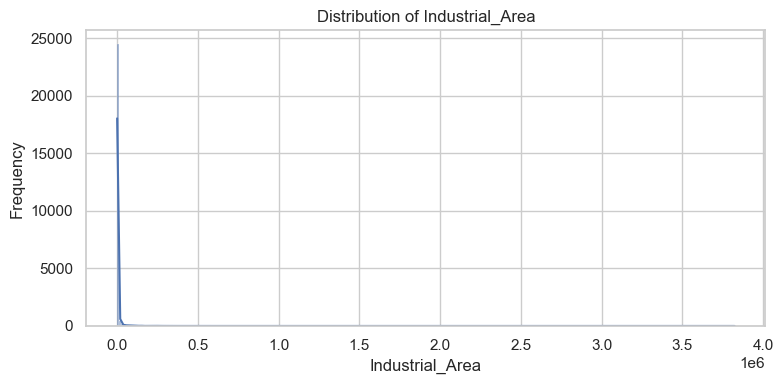

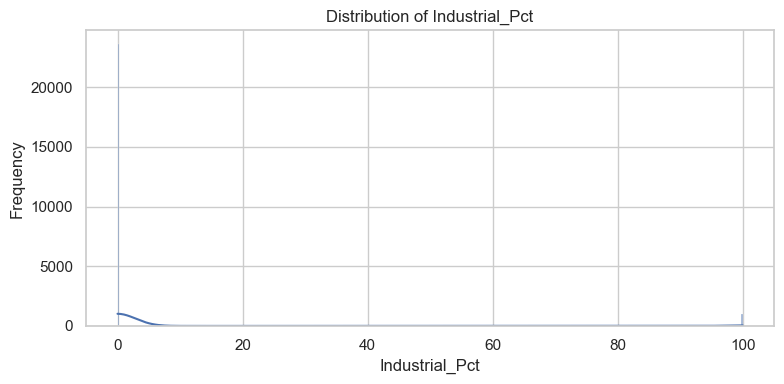

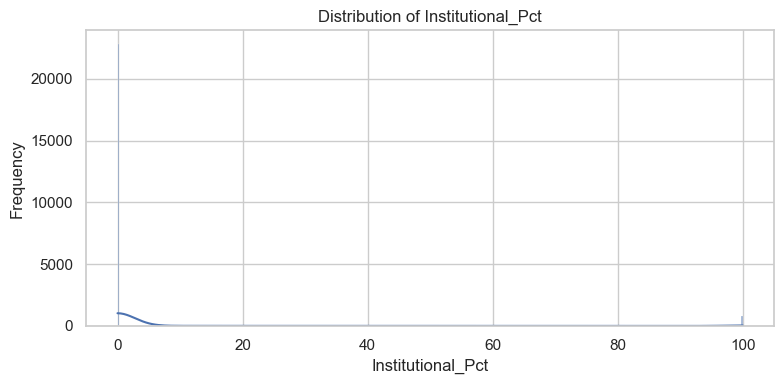

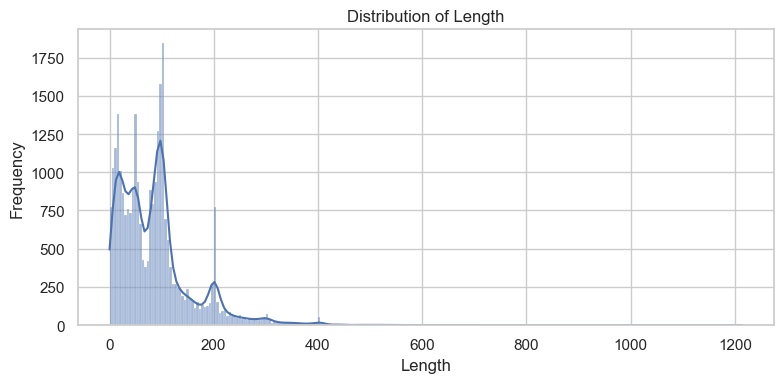

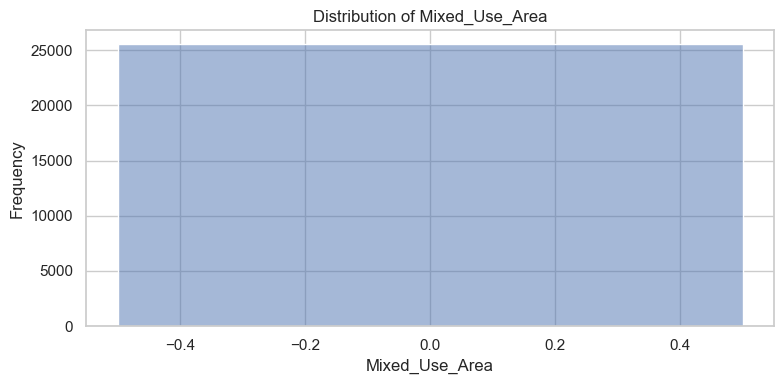

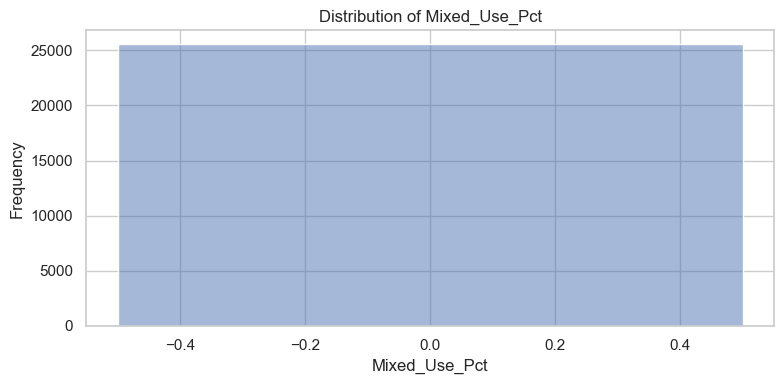

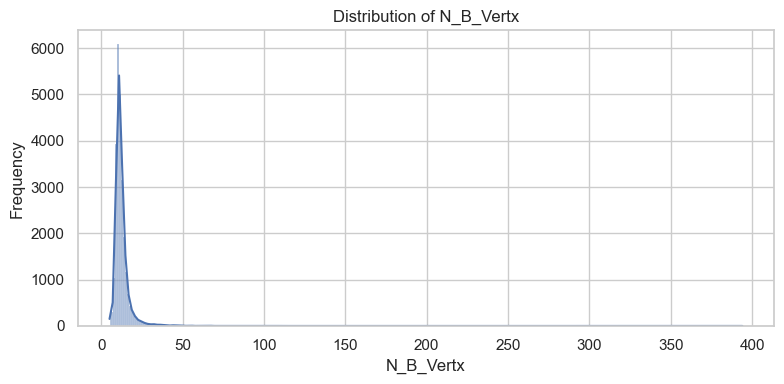

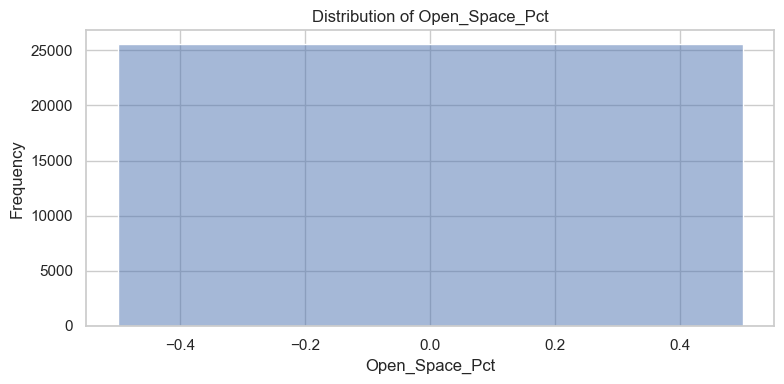

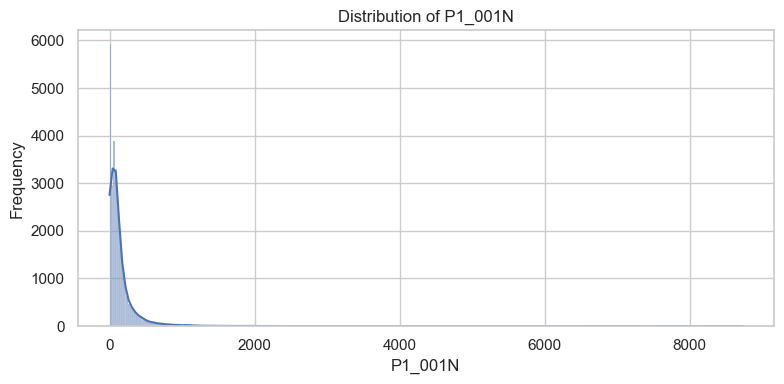

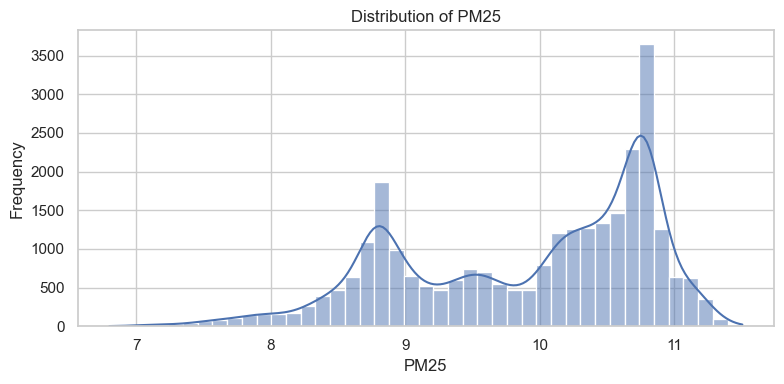

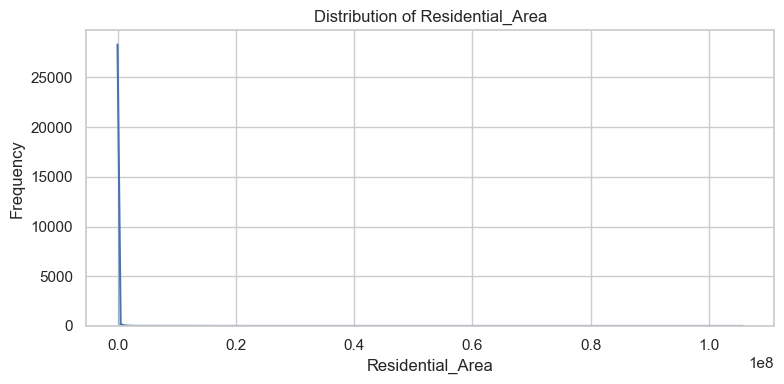

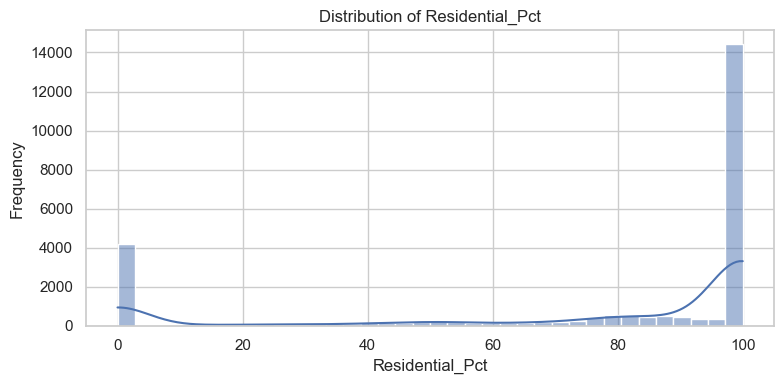

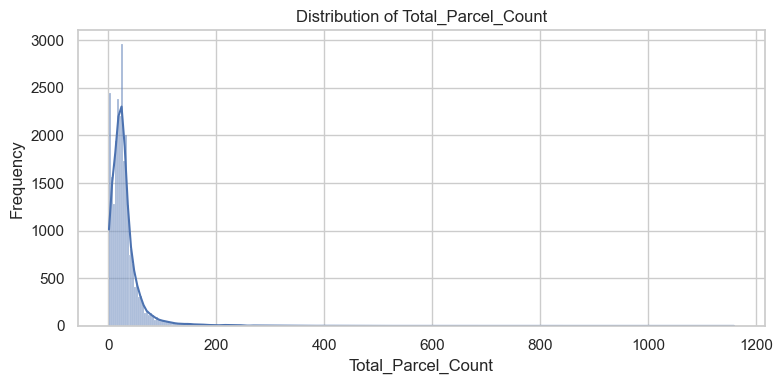

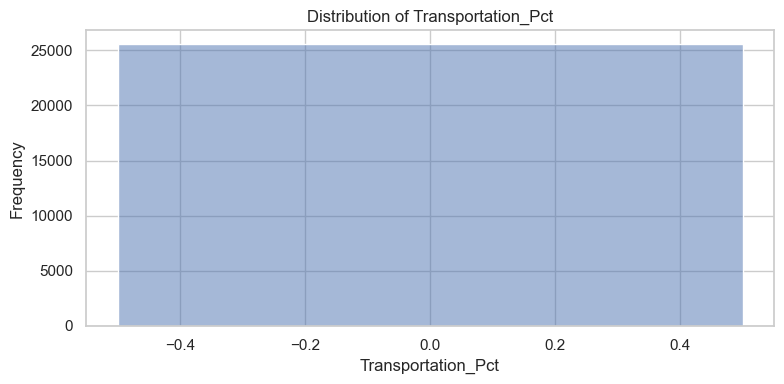

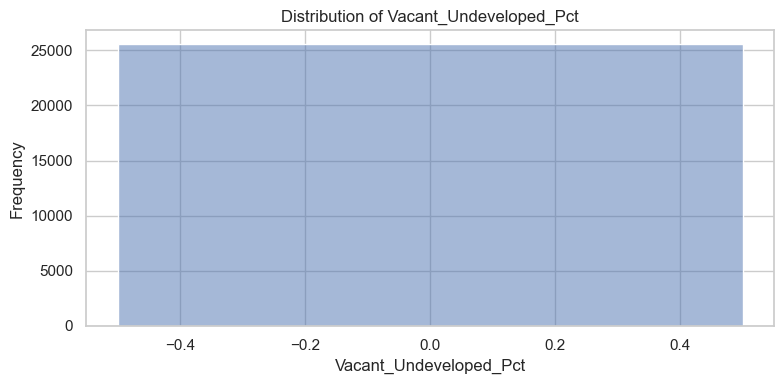

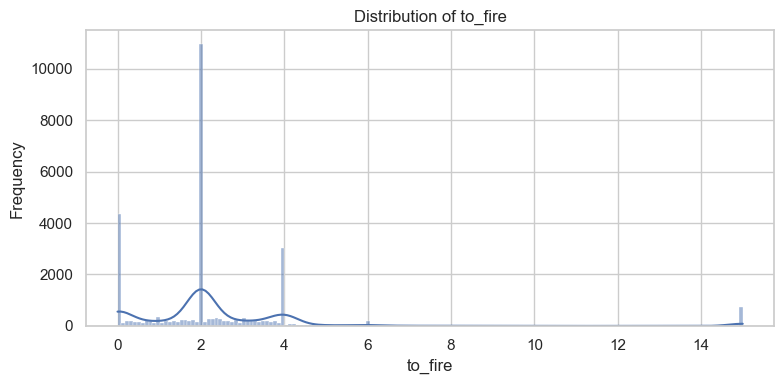

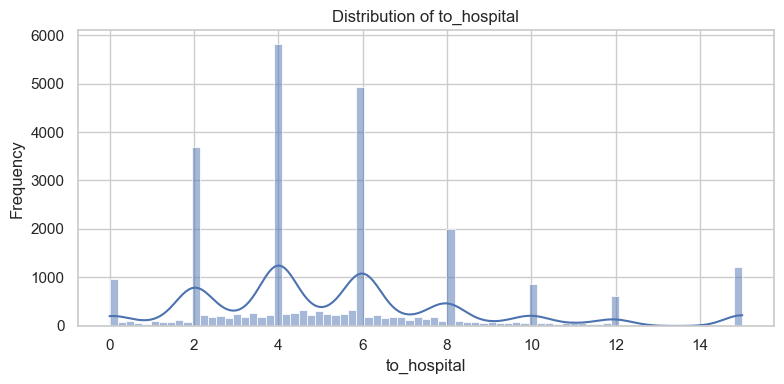

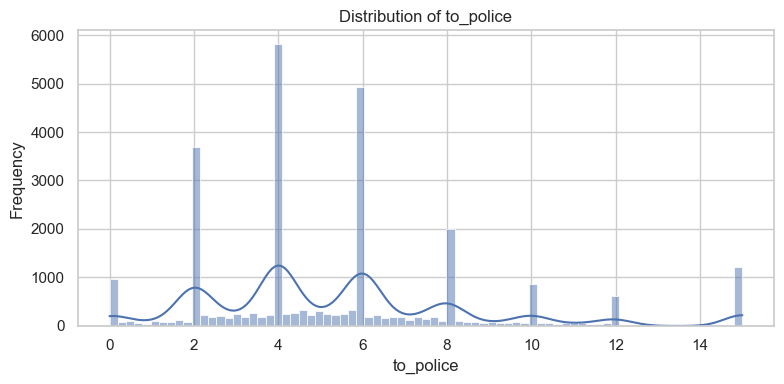

In [10]:
# Distribution plots for numerical features

for feature in eda_numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

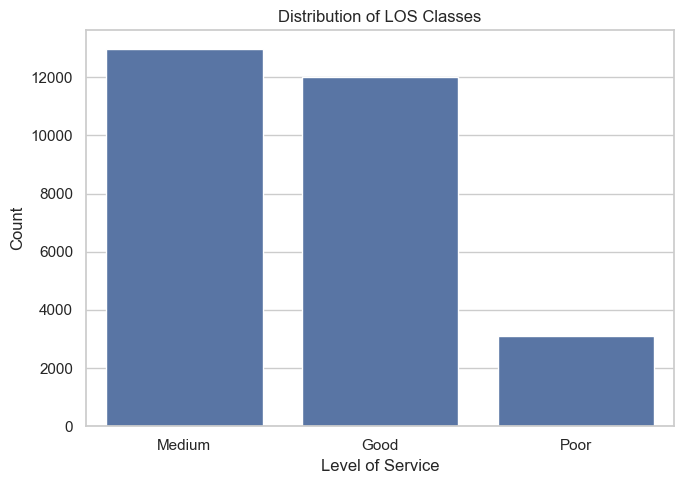

In [11]:
# Target distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=target, order=df[target].value_counts().index)
plt.title("Distribution of LOS Classes")
plt.xlabel("Level of Service")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

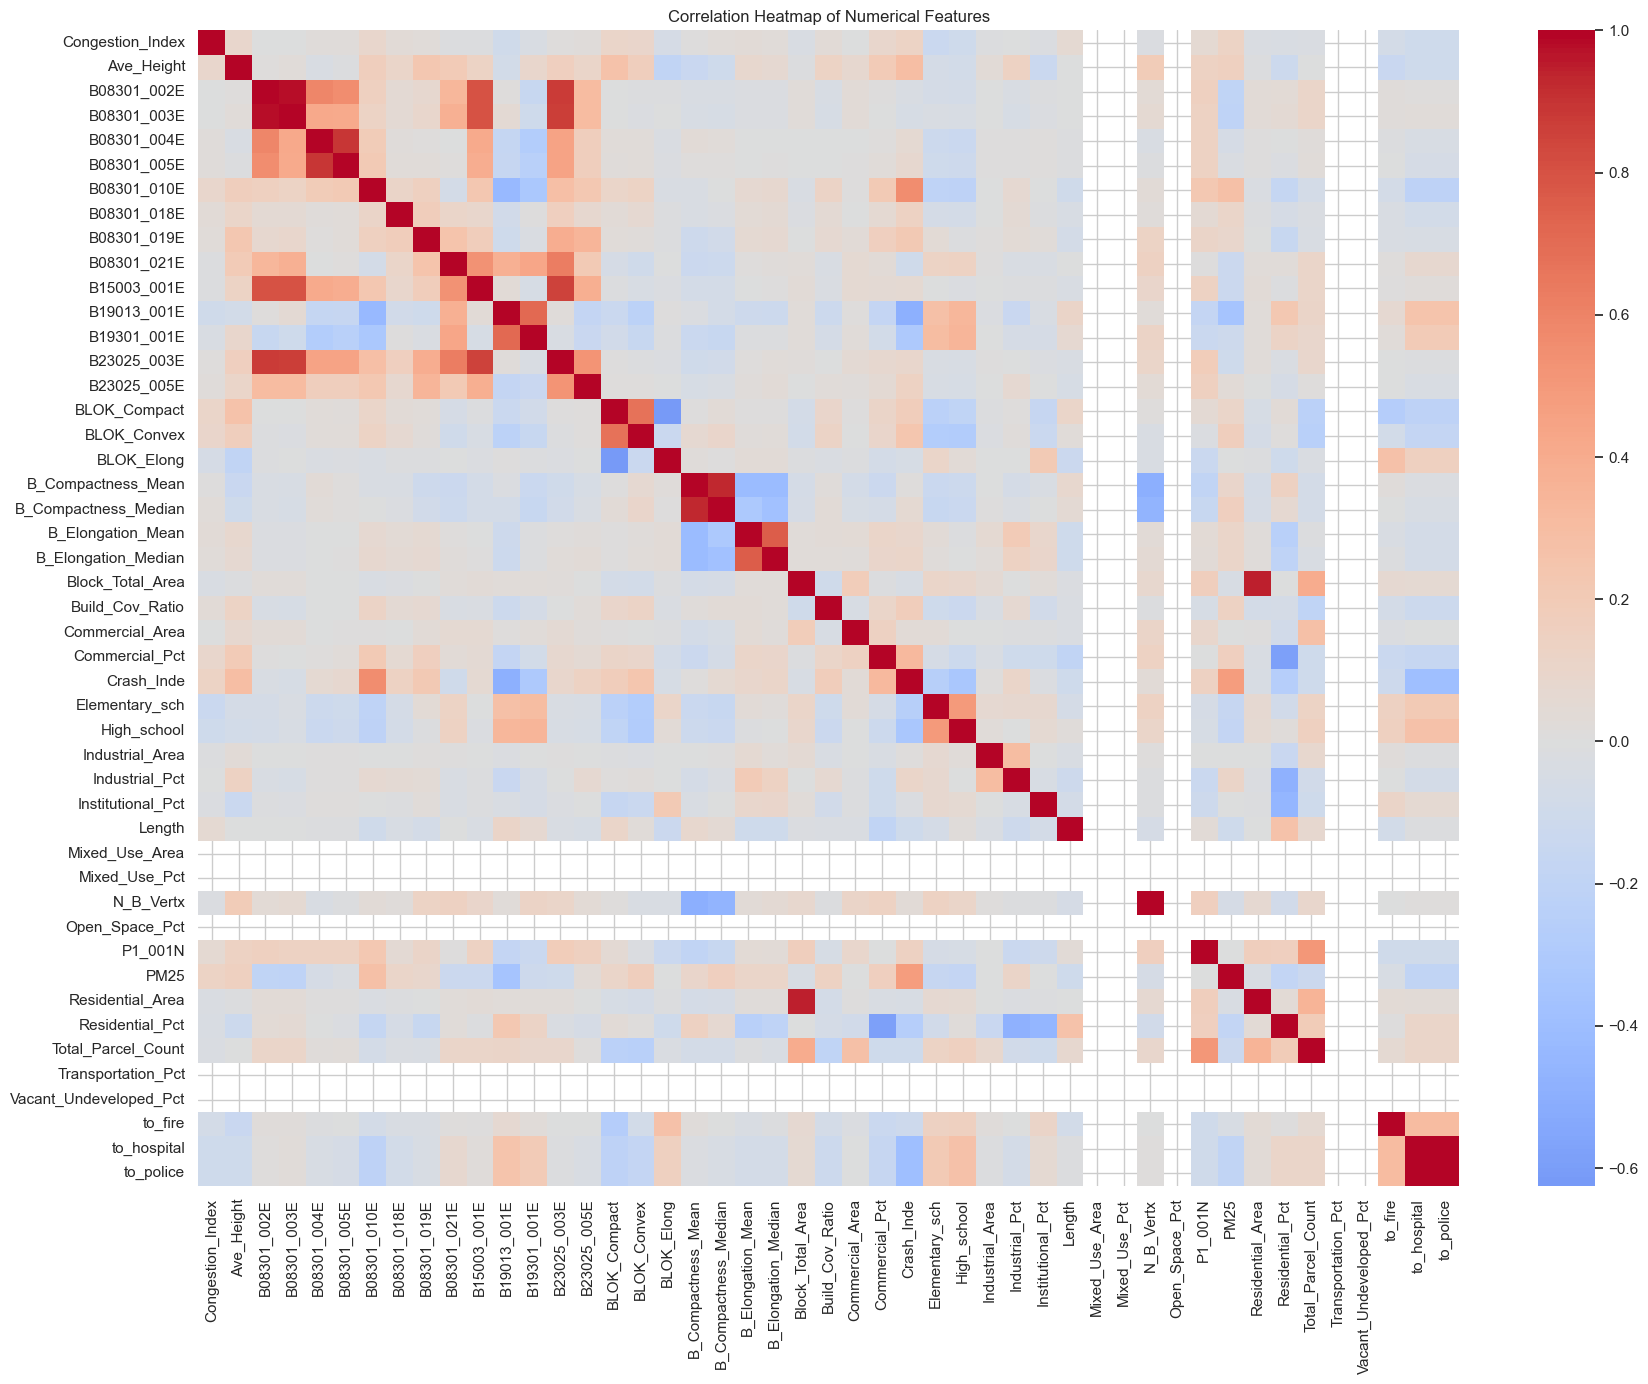

In [12]:
# Correlation heatmap of numerical input features

corr = df[eda_numeric_features].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

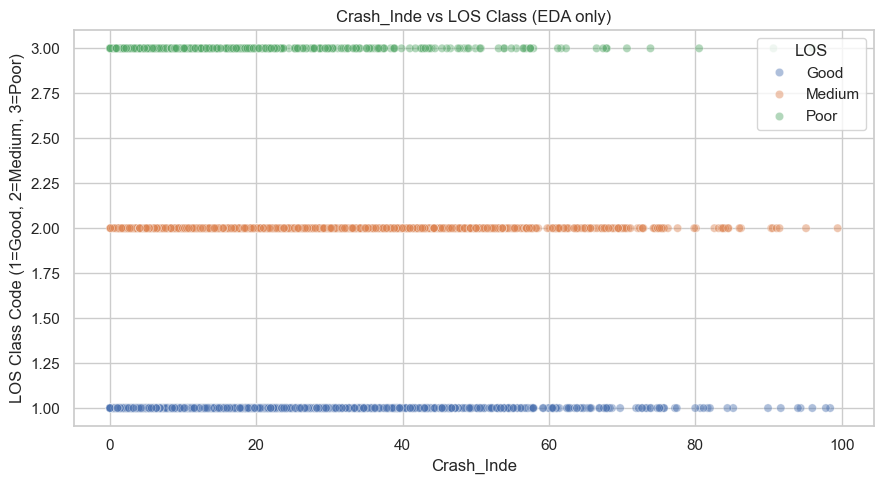

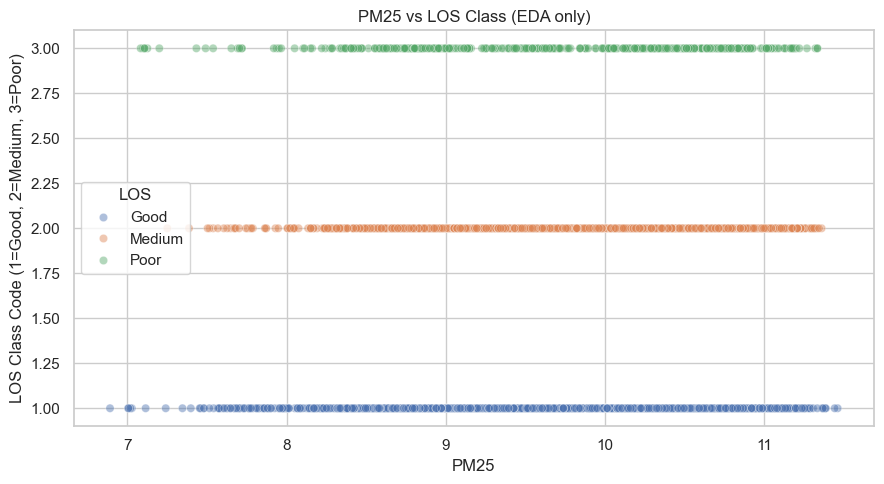

In [13]:
los_plot_code = {
    "Good": 1,
    "Medium": 2,
    "Poor": 3
}

df["_LOS_plot_code"] = df[target].map(los_plot_code)

scatter_features = ["Crash_Inde", "PM25"]

for feature in scatter_features:
    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=df.sample(min(5000, len(df)), random_state=RANDOM_STATE),
        x=feature,
        y="_LOS_plot_code",
        hue=target,
        alpha=0.45
    )
    plt.title(f"{feature} vs LOS Class (EDA only)")
    plt.xlabel(feature)
    plt.ylabel("LOS Class Code (1=Good, 2=Medium, 3=Poor)")
    plt.legend(title="LOS")
    plt.tight_layout()
    plt.show()

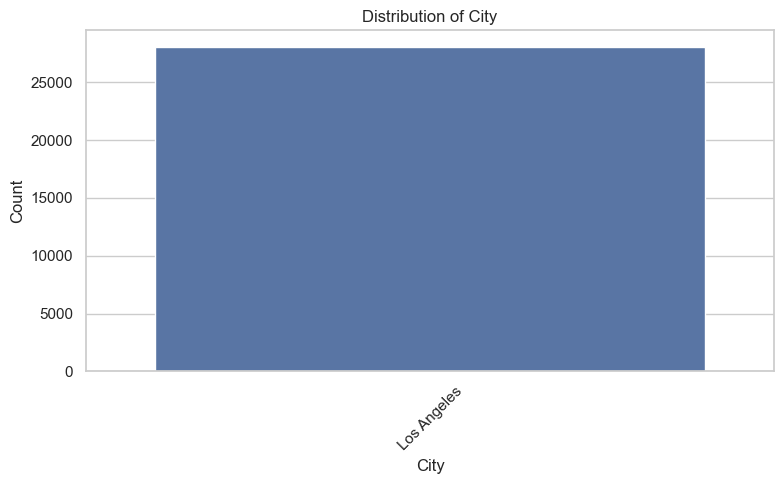

In [14]:
# Categorical feature visualisations

for feature in eda_categorical_features:
    plt.figure(figsize=(8, 5))
    order = df[feature].value_counts(dropna=False).index
    sns.countplot(data=df, x=feature, order=order)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

df.drop(columns=["_LOS_plot_code"], inplace=True)

# 3. Preprocessing & Feature Engineering

In [15]:
data = df.copy()

# Remove duplicate rows
before = len(data)
data = data.drop_duplicates().reset_index(drop=True)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", len(data))
print("Duplicates removed:", before - len(data))

Rows before duplicate removal: 28092
Rows after duplicate removal: 28091
Duplicates removed: 1


In [16]:
missing_after_duplicates = data.isnull().sum().sort_values(ascending=False)
display(missing_after_duplicates[missing_after_duplicates > 0])

Build_Cov_Ratio           3283
B19013_001E               2722
Block_Total_Area          2572
Mixed_Use_Area            2572
Mixed_Use_Pct             2572
Residential_Area          2572
Open_Space_Pct            2572
Vacant_Undeveloped_Pct    2572
Transportation_Pct        2572
Total_Parcel_Count        2572
Residential_Pct           2572
Institutional_Pct         2572
Commercial_Area           2572
Industrial_Pct            2572
Industrial_Area           2572
Commercial_Pct            2572
B_Compactness_Median      2447
B_Elongation_Mean         2447
N_B_Vertx                 2447
B_Elongation_Median       2447
B_Compactness_Mean        2447
B19301_001E                262
Elementary_sch             138
High_school                133
Crash_Inde                   8
Ave_Height                   2
B23025_005E                  2
B08301_004E                  2
B08301_003E                  2
B08301_005E                  2
B08301_010E                  2
B08301_002E                  2
B08301_0

In [17]:
# Feature engineering

# Mean distance to emergency services.
# Lower values can represent better emergency-service accessibility.
data["Emergency_Access_Mean"] = data[
    ["to_fire", "to_hospital", "to_police"]
].mean(axis=1)

# Built-up intensity relative to block area.
# This is a domain-derived ratio rather than a copy of the target.
data["Built_Area_Intensity"] = (
    data["Build_Cov_Ratio"] * data["Block_Total_Area"]
)

print("New engineered features:")
print("- Emergency_Access_Mean")
print("- Built_Area_Intensity")

New engineered features:
- Emergency_Access_Mean
- Built_Area_Intensity


In [18]:
print("LOS_actual_numeric unique values:", data["LOS_actual_numeric"].unique())
print("\nCongestion_Index vs LOS_actual:")
display(pd.crosstab(data["Congestion_Index"], data["LOS_actual"]))

LOS_actual_numeric unique values: [2. 3. 1.]

Congestion_Index vs LOS_actual:


LOS_actual,Good,Medium,Poor
Congestion_Index,,,
0.0,0,0,646
1.0,5434,0,0
2.0,6577,0,0
3.0,0,7985,0
4.0,0,4977,0
5.0,0,0,1828
6.0,0,0,644


In [19]:
# Define features and target

target = "LOS_actual"

drop_columns = [
    target,
    "LOS_actual_numeric",
    "GEOID20",
    "City",
    "Congestion_Index"
]

X = data.drop(columns=drop_columns)
y = data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", sorted(y.unique()))

X shape: (28091, 48)
y shape: (28091,)
Classes: ['Good', 'Medium', 'Poor']


In [20]:
# Identify categorical and numerical model features

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
[]

Numerical features:
['Ave_Height', 'B08301_002E', 'B08301_003E', 'B08301_004E', 'B08301_005E', 'B08301_010E', 'B08301_018E', 'B08301_019E', 'B08301_021E', 'B15003_001E', 'B19013_001E', 'B19301_001E', 'B23025_003E', 'B23025_005E', 'BLOK_Compact', 'BLOK_Convex', 'BLOK_Elong', 'B_Compactness_Mean', 'B_Compactness_Median', 'B_Elongation_Mean', 'B_Elongation_Median', 'Block_Total_Area', 'Build_Cov_Ratio', 'Commercial_Area', 'Commercial_Pct', 'Crash_Inde', 'Elementary_sch', 'High_school', 'Industrial_Area', 'Industrial_Pct', 'Institutional_Pct', 'Length', 'Mixed_Use_Area', 'Mixed_Use_Pct', 'N_B_Vertx', 'Open_Space_Pct', 'P1_001N', 'PM25', 'Residential_Area', 'Residential_Pct', 'Total_Parcel_Count', 'Transportation_Pct', 'Vacant_Undeveloped_Pct', 'to_fire', 'to_hospital', 'to_police', 'Emergency_Access_Mean', 'Built_Area_Intensity']


In [21]:
# Stratified train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest class distribution:")
display(y_test.value_counts(normalize=True).mul(100).round(2))

Training set: (22472, 48)
Test set: (5619, 48)

Training class distribution:


LOS_actual
Medium    46.14
Good      42.76
Poor      11.10
Name: proportion, dtype: float64


Test class distribution:


LOS_actual
Medium    46.15
Good      42.75
Poor      11.11
Name: proportion, dtype: float64

In [22]:
# training-set IQR

iqr_bounds = {}

for col in numerical_features:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1

    if pd.isna(iqr) or iqr == 0:
        lower = q1
        upper = q3
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

    iqr_bounds[col] = (lower, upper)

X_train_num = X_train[numerical_features].copy()
X_test_num = X_test[numerical_features].copy()

for col, (lower, upper) in iqr_bounds.items():
    X_train_num[col] = X_train_num[col].clip(lower, upper)
    X_test_num[col] = X_test_num[col].clip(lower, upper)

print("Training-set IQR capping completed.")

Training-set IQR capping completed.


In [24]:
# Numerical imputation

numeric_imputer = SimpleImputer(strategy="median")

X_train_num_imputed = numeric_imputer.fit_transform(X_train_num)
X_test_num_imputed = numeric_imputer.transform(X_test_num)

print("Numerical preprocessing completed.")
print("Shape:", X_train_num_imputed.shape)


Numerical preprocessing completed.
Shape: (22472, 48)


In [30]:
# Categorical imputation

if len(categorical_features) == 0:
    print("No categorical features found. Categorical imputation skipped.")
else:
    X_train_cat = X_train[categorical_features].copy()
    X_test_cat = X_test[categorical_features].copy()

    categorical_imputer = SimpleImputer(strategy="most_frequent")

    X_train_cat_imputed = categorical_imputer.fit_transform(X_train_cat)
    X_test_cat_imputed = categorical_imputer.transform(X_test_cat)

    print("Categorical imputation completed.")
    print("Shape:", X_train_cat_imputed.shape)

No categorical features found. Categorical imputation skipped.


In [32]:
# Categorical encoding

if len(categorical_features) == 0:
    print("No categorical features found.")
    print("Categorical encoding skipped.")
    
    # Create empty arrays so later code does not give NameError
    X_train_cat_encoded = np.empty((X_train.shape[0], 0))
    X_test_cat_encoded = np.empty((X_test.shape[0], 0))

else:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

    X_train_cat_encoded = encoder.fit_transform(
        X_train_cat_imputed
    )

    X_test_cat_encoded = encoder.transform(
        X_test_cat_imputed
    )

    print("Encoded categorical training shape:", X_train_cat_encoded.shape)
    print("Encoded categorical testing shape:", X_test_cat_encoded.shape)

No categorical features found.
Categorical encoding skipped.


In [34]:
# Combine numerical and categorical features

X_train_processed = np.hstack([
    X_train_num_imputed,
    X_train_cat_encoded
])

X_test_processed = np.hstack([
    X_test_num_imputed,
    X_test_cat_encoded
])

feature_names = numerical_features

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)
print("Number of final features :", len(feature_names))

Processed training shape: (22472, 48)
Processed testing shape : (5619, 48)
Number of final features : 48


In [35]:
# Standard scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Scaled training shape: (22472, 48)
Scaled testing shape : (5619, 48)
